In [1]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import sys
sys.path.append("../")
from src.preprocessing.pdf_extractor import PDFExtractor
from src.preprocessing.document_validator import DocumentValidator

In [2]:
# ---------------------------------------------------------
# LOAD FILES
# ---------------------------------------------------------

VOCAB_FILE = "../data/vocabulary/ministry_tfidf_vocab.json"
EMBED_FILE = "../data/embeddings/ministry_embeddings3.json"


def load_vocab():
    with open(VOCAB_FILE, "r") as f:
        return json.load(f)


def load_embeddings():
    with open(EMBED_FILE, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

In [3]:
STOPWORD_FILE = "../data/stopwords/GBparl_stopwords-empirical.txt"

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def load_stopwords(custom_file):

    stopwords = set(ENGLISH_STOP_WORDS)

    # load domain stopwords
    with open(custom_file, "r", encoding="utf-8") as f:
        for line in f:
            word = line.strip().lower()
            if word:
                stopwords.add(word)

    return stopwords

stopwords = load_stopwords(STOPWORD_FILE)

In [4]:

import re

def clean_text(text, stopwords=None):

    # remove bullet characters
    text = text.replace("\uf0b7", " ")

    # remove numbering like "1." "2."
    text = re.sub(r"\n?\d+\.\s*", " ", text)

    # replace newlines with space
    text = text.replace("\n", " ")

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)
    
    # remove all punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # keep only alphabets, remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # make everything lowercase
    text = text.lower()

    # tokenize
    words = text.split()

    if stopwords:
        words = [w for w in words if w not in stopwords and len(w) > 2]

    return " ".join(words)

In [5]:
# ---------------------------------------------------------
# EXTRACT PARAGRAPHS FROM PDF
# ---------------------------------------------------------

def extract_paragraphs(pdf_path, skip_length=10):

    extractor = PDFExtractor()
    result = extractor.extract(pdf_path)

    paragraphs = [clean_text(seg["paragraph"], stopwords) for seg in result["segments"] if len(seg["paragraph"].split()) > skip_length]
    speakers = [seg["speaker"] for seg in result["segments"]]

    return paragraphs, speakers

In [6]:
# ---------------------------------------------------------
# VALIDATE DOCUMENT
# ---------------------------------------------------------

def validate(text):

    validator = DocumentValidator(vocab_path="../data/vocabulary/parliament_vocab.txt")
    results = validator.validate_document(text)

    return results

In [7]:
# ---------------------------------------------------------
# VOCAB BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_vocab(paragraph, ministry_vocab):

    words = paragraph.lower().split()

    scores = {}

    for ministry, vocab in ministry_vocab.items():

        count = 0

        for term in vocab:
            if term.lower() in paragraph.lower():
                count += 1

        scores[ministry] = count

    total = sum(scores.values()) + 1e-9

    probs = {k: v / total for k, v in scores.items()}

    return probs


# ---------------------------------------------------------
# EMBEDDING BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_embedding(paragraph, model, ministry_embeddings, method="max", k=3):

    p_emb = model.encode(paragraph).reshape(1, -1)

    scores = {}

    for ministry, m_embs in ministry_embeddings.items():
        # m_embs shape: (num_paragraphs, embedding_dim)

        sims = cosine_similarity(p_emb, m_embs)[0]

        if method == "max":
            score = np.max(sims)
        elif method == "mean":
            score = np.mean(sims)
        elif method == "topk":
            topk = np.sort(sims)[-k:]
            score = np.mean(topk)
        else:
            raise ValueError("method must be 'max' or 'mean'")

        scores[ministry] = float(score)

    # softmax normalization
    exp_scores = np.exp(list(scores.values()))
    probs = exp_scores / np.sum(exp_scores)

    return dict(zip(scores.keys(), probs))

In [68]:
# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def run_pipeline(pdf_path):

    print(f"Processing: {pdf_path}")
    print("-" * 50)

    paragraphs, speaker = extract_paragraphs(pdf_path, skip_length=10)

    full_text = "\n\n".join(paragraphs)

    validation = validate(full_text)

    print("VALIDATION RESULTS:")
    print(json.dumps(validation, indent=4))

    if not validation["is_valid"]:
        print("Document failed validation")
        return

    print("\nLoading ministry vocab...")
    ministry_vocab = load_vocab()

    print("Loading ministry embeddings...")
    ministry_embeddings = load_embeddings()

    model = SentenceTransformer("all-MiniLM-L6-v2", cache_folder="../models")

    print("\nClassifying paragraphs...\n")

    results = []

    for i, para in enumerate(paragraphs):

        vocab_probs = classify_vocab(para, ministry_vocab)

        embed_probs = classify_embedding(
            para,
            model,
            ministry_embeddings,
            method="topk", # "max", "mean", or "topk"
            k=3
        )

        results.append({
            "paragraph_id": i,
            "paragraph": para,
            "speaker": speaker[i],
            "vocab_distribution": vocab_probs,
            "embedding_distribution": embed_probs
        })

        print("=" * 80)
        print(f"Paragraph {i}")
        # print(para[:200])

        print("\nTop vocab ministry:")
        print(sorted(vocab_probs.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop embedding ministry:")
        print(sorted(embed_probs.items(), key=lambda x: x[1], reverse=True)[:3])

    return results

In [69]:
# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------

# if __name__ == "__main__":

file_name = "test.pdf"
file_path = f"../data/uploads/{file_name}"

results = run_pipeline(file_path)

Processing: ../data/uploads/test.pdf
--------------------------------------------------
VALIDATION RESULTS:905
{
    "is_valid": true,
    "is_english": true,
    "validation_errors": [],
    "vocab_size": 116,
    "required_vocab_matches": 5,
    "parliament_confidence": 0.06896551724137931,
    "matched_vocab_terms": [
        "act",
        "budget",
        "gazette",
        "government",
        "half",
        "motion",
        "schedule",
        "speaker"
    ]
}

Loading ministry vocab...
Loading ministry embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Classifying paragraphs...

Paragraph 0

Top vocab ministry:
[('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_', 0.14285714285034012), ('Ministry_of_Parliamentary_Affairs_MPA_', 0.0952380952335601), ('Ministry_of_Law_and_Justice_MoLJ_', 0.04761904761678005)]

Top embedding ministry:
[('Ministry_of_Parliamentary_Affairs_MPA_', np.float64(0.021662965649730442)), ('Ministry_of_External_Affairs_MEA_', np.float64(0.02038341229364611)), ('Ministry_of_Youth_Affairs_and_Sports_MoYAS_', np.float64(0.02004152361729827))]
Paragraph 1

Top vocab ministry:
[('Ministry_of_Coal_MoC_', 0.22222222219753085), ('Ministry_of_AYUSH_MoA_', 0.11111111109876542), ('Ministry_of_Textiles_MoT_', 0.11111111109876542)]

Top embedding ministry:
[('Ministry_of_Women_and_Child_Development_MoWCD_', np.float64(0.020254062509574046)), ('Ministry_of_Development_of_North_Eastern_Region_MDoNER_', np.float64(0.020122393507725513)), ('Ministry_of_Parliamentary_Affairs_MPA_', np.float64(0.020107510492873484))]
Par

In [70]:
len(results)

181

In [71]:
# find for which ministries the vocab and embedding classifications match
matches = []
for res in results:
    vocab_top = max(res["vocab_distribution"], key=res["vocab_distribution"].get)
    embed_top = max(res["embedding_distribution"], key=res["embedding_distribution"].get)

    if vocab_top == embed_top:
        matches.append({
            "paragraph_id": res["paragraph_id"],
            "speaker": res["speaker"],
            "ministry": vocab_top,
            "paragraph_snippet": res["paragraph"]
        })
print("\nParagraphs where vocab and embedding classifications match:")
for match in matches:
    print(f"Paragraph {match['paragraph_id']} - Speaker: {match['speaker']} - Ministry: {match['ministry']}")
    print(f"Snippet: {match['paragraph_snippet']}")
    print("-" * 80)


Paragraphs where vocab and embedding classifications match:
Paragraph 9 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
Snippet: prime dhandhaanya krishi yojana developing agri districts programme motivated success aspirational districts programme undertake prime dhandhaanya krishi yojana partnership states convergence existing schemes specialized measures programme cover districts low productivity moderate crop intensity belowaverage credit parameters aims enhance agricultural productivity adopt crop diversification sustainable agriculture practices augment postharvest storage panchayat block level improve irrigation facilities facilitate availability longterm shortterm credit programme likely help crore farmers
--------------------------------------------------------------------------------
Paragraph 10 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Rural_Development_MoRD_
Snippet: building rural prosperity resilience comprehensive multisector

In [72]:
len(matches)

50

In [ ]:
# total paragraphs = 181
# for max
# matches = 46
# top 2 = 26
# top 3 = 39
# top 4 = 49
# top 5 = 56

# for mean
# matches = 39
# top 2 = 35
# top 3 = 49
# top 4 = 62
# top 5 = 72

# for topk (k=3)
# matches = 50
# top 2 = 30
# top 3 = 38
# top 4 = 47
# top 5 = 53

In [79]:
# find top 5 errors for ministry classification 
# (vocab top 1 != embedding top 1 and vocab top 1 is comming in top 5 of embedding or vice versa)
errors = []
for res in results:
    vocab_top = max(res["vocab_distribution"], key=res["vocab_distribution"].get)
    embed_top = max(res["embedding_distribution"], key=res["embedding_distribution"].get)

    if vocab_top != embed_top:
        vocab_top_5 = sorted(res["vocab_distribution"].items(), key=lambda x: x[1], reverse=True)[:2]
        embed_top_5 = sorted(res["embedding_distribution"].items(), key=lambda x: x[1], reverse=True)[:2]

        vocab_top_5_ministries = [v[0] for v in vocab_top_5]
        embed_top_5_ministries = [e[0] for e in embed_top_5]

        if (vocab_top in embed_top_5_ministries) or (embed_top in vocab_top_5_ministries):
            errors.append({
                "paragraph_id": res["paragraph_id"],
                "speaker": res["speaker"],
                "vocab_top": vocab_top,
                "embed_top": embed_top,
                "paragraph_snippet": res["paragraph"]
            })
print("\nClassification errors where vocab and embedding disagree but one is in top 5 of the other:")
for error in errors:
    print(f"Paragraph {error['paragraph_id']} - Speaker: {error['speaker']} - Vocab Top: {error['vocab_top']} - Embed Top: {error['embed_top']}")
    print(f"Snippet: {error['paragraph_snippet']}")
    print("-" * 80)


Classification errors where vocab and embedding disagree but one is in top 5 of the other:
Paragraph 0 - Speaker: HON. SPEAKER - Vocab Top: Ministry_of_Statistics_and_Programme_Implementation_MoSPI_ - Embed Top: Ministry_of_Parliamentary_Affairs_MPA_
Snippet: honble members ample opportunity participate discussion motion thanks presidents address budget
--------------------------------------------------------------------------------
Paragraph 18 - Speaker: SHRIMATI NIRMALA SITHARAMAN - Vocab Top: Ministry_of_Food_Processing_Industries_MoFPI_ - Embed Top: Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
Snippet: makhana board bihar special opportunity bihar makhana board established state improve production processing value addition marketing makhana engaged activities organized fpos board provide handholding training makhana farmers work receive benefits relevant schemes
--------------------------------------------------------------------------------
Paragraph 39 - Speaker: SHRIMATI

In [80]:
len(errors)

30

In [81]:
import numpy as np

def compute_document_distribution(results, method="embedding"):
    
    ministry_scores = {}

    for item in results:

        if method == "embedding":
            dist = item["embedding_distribution"]
        else:
            dist = item["vocab_distribution"]

        for ministry, prob in dist.items():
            ministry_scores[ministry] = ministry_scores.get(ministry, 0) + prob

    # normalize
    total = sum(ministry_scores.values())

    ministry_scores = {
        k: v / total
        for k, v in ministry_scores.items()
    }

    return ministry_scores

In [82]:
def print_top_ministries(distribution, top_k=10):

    sorted_min = sorted(
        distribution.items(),
        key=lambda x: x[1],
        reverse=True
    )

    print("\nTOP MINISTRIES IN DOCUMENT\n")

    for ministry, score in sorted_min[:top_k]:
        print(f"{ministry:40} {score:.4f}")

In [83]:
import matplotlib.pyplot as plt

def plot_ministry_distribution(distribution, top_k=10):

    sorted_min = sorted(
        distribution.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    ministries = [x[0] for x in sorted_min]
    scores = [x[1] for x in sorted_min]

    plt.figure(figsize=(12,6))

    plt.barh(ministries, scores)

    plt.xlabel("Probability")
    plt.title("Document Ministry Distribution")

    plt.gca().invert_yaxis()

    plt.show()

In [84]:
def plot_comparison(vocab_dist, embed_dist, top_k=10):

    vocab_sorted = sorted(vocab_dist.items(), key=lambda x: x[1], reverse=True)[:top_k]
    embed_sorted = sorted(embed_dist.items(), key=lambda x: x[1], reverse=True)[:top_k]

    ministries = [x[0] for x in embed_sorted]

    vocab_scores = [vocab_dist.get(m,0) for m in ministries]
    embed_scores = [embed_dist.get(m,0) for m in ministries]

    x = np.arange(len(ministries))

    plt.figure(figsize=(12,6))

    plt.bar(x-0.2, vocab_scores, width=0.4, label="Vocab")
    plt.bar(x+0.2, embed_scores, width=0.4, label="Embedding")

    plt.xticks(x, ministries, rotation=60)
    plt.ylabel("Score")

    plt.title("Ministry Distribution Comparison")

    plt.legend()

    plt.show()

In [85]:
def build_heatmap_matrix(results, method="embedding"):

    ministries = list(results[0][f"{method}_distribution"].keys())
    num_paragraphs = len(results)

    matrix = np.zeros((len(ministries), num_paragraphs))

    for j, para in enumerate(results):

        dist = para[f"{method}_distribution"]

        for i, ministry in enumerate(ministries):

            matrix[i, j] = dist[ministry]

    return matrix, ministries

import matplotlib.pyplot as plt

def plot_ministry_heatmap(matrix, ministries):

    plt.figure(figsize=(16,8))

    plt.imshow(matrix, aspect='auto')

    plt.colorbar(label="Ministry Relevance")

    plt.ylabel("Ministries")
    plt.xlabel("Paragraph Index")

    plt.yticks(range(len(ministries)), ministries)

    plt.title("Ministry Discussion Heatmap Across Paragraphs")

    plt.show()

In [86]:
vocab_doc_dist = compute_document_distribution(results, "vocab")
embed_doc_dist = compute_document_distribution(results, "embedding")

print_top_ministries(embed_doc_dist)


TOP MINISTRIES IN DOCUMENT

Ministry_of_Commerce_and_Industry_MoCI_  0.0199
Ministry_of_Finance_MoF_                 0.0198
Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_ 0.0196
Ministry_of_Micro_Small_Medium_Enterprises_MoME_ 0.0196
Ministry_of_Communications_MoC_          0.0195
Ministry_of_Development_of_North_Eastern_Region_MDoNER_ 0.0194
Ministry_of_Heavy_Industries_MoHI_       0.0194
Ministry_of_Cooperation_MoC_             0.0193
Ministry_of_Electronics_and_Information_Technology_MeitY_ 0.0193
Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_ 0.0192


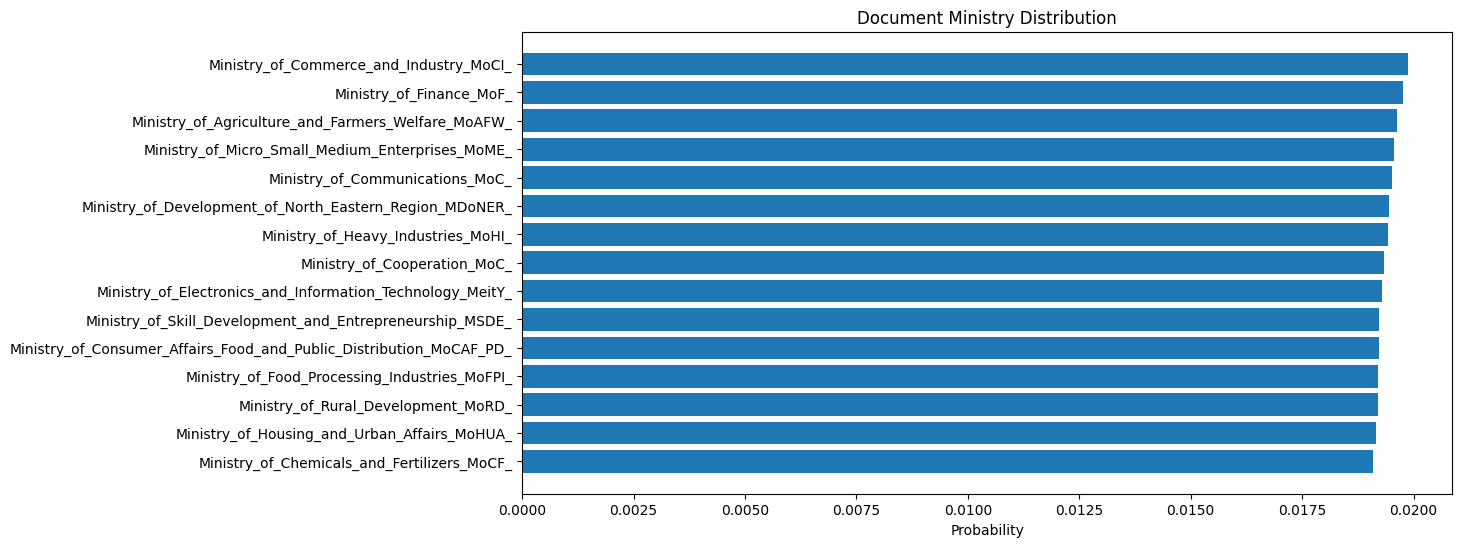

In [87]:
plot_ministry_distribution(embed_doc_dist, top_k=15)

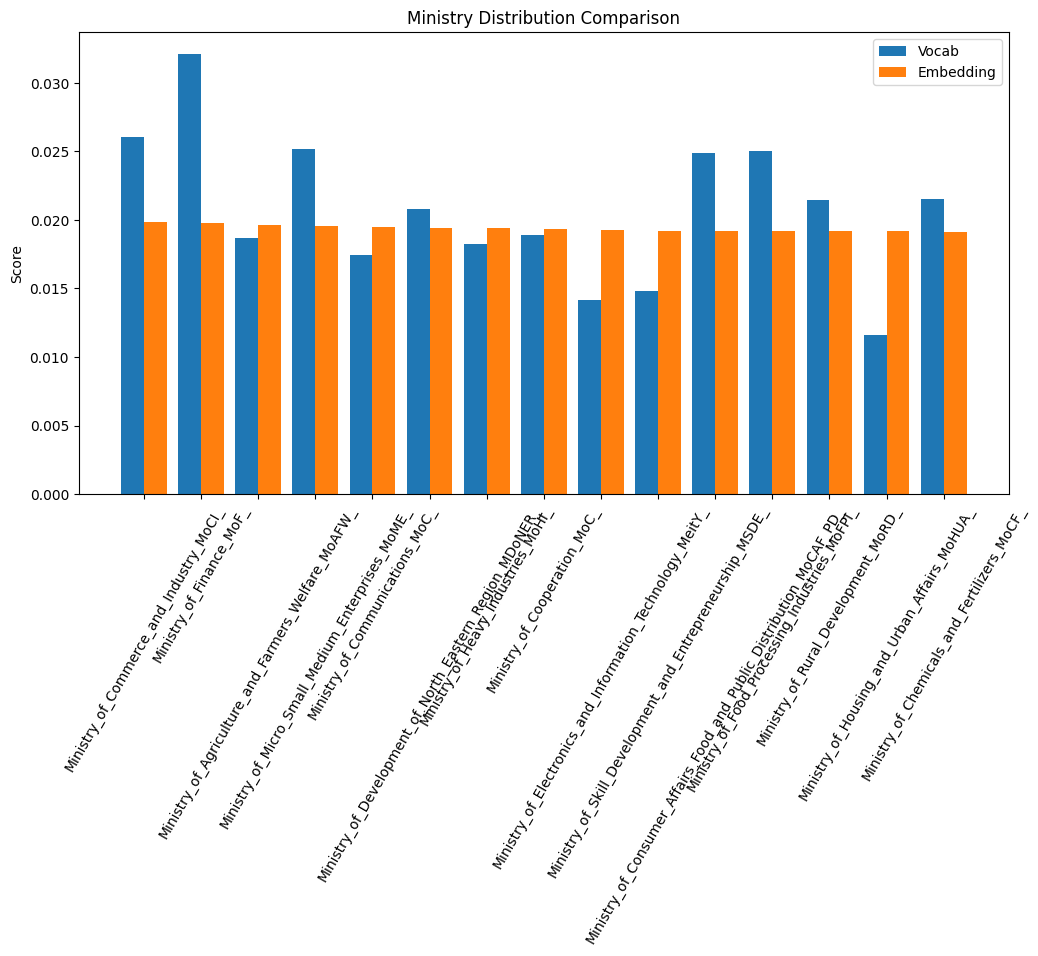

In [88]:
plot_comparison(vocab_doc_dist, embed_doc_dist, top_k=15)

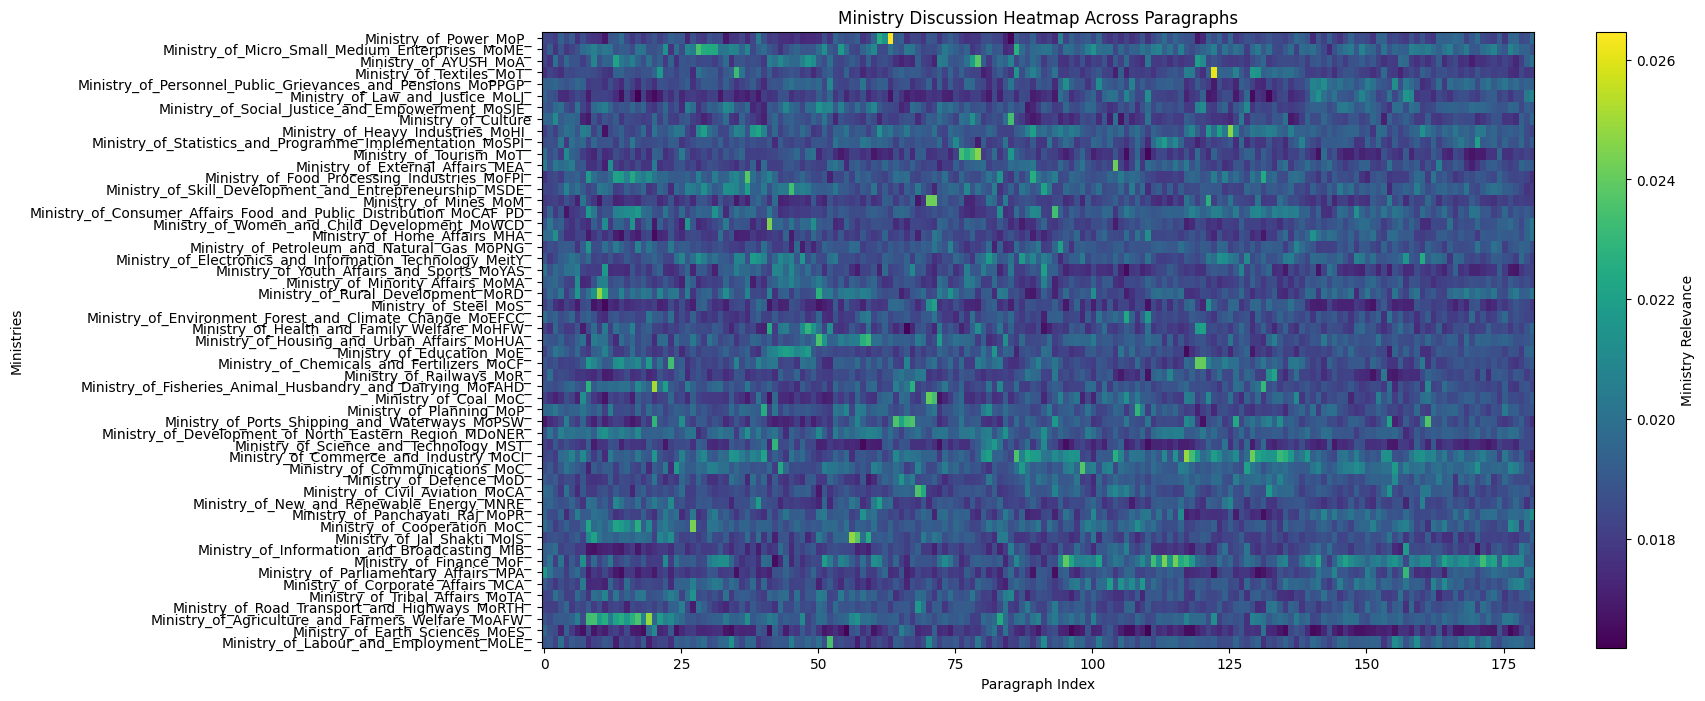

In [89]:
matrix, ministries = build_heatmap_matrix(results, "embedding")

plot_ministry_heatmap(matrix, ministries)

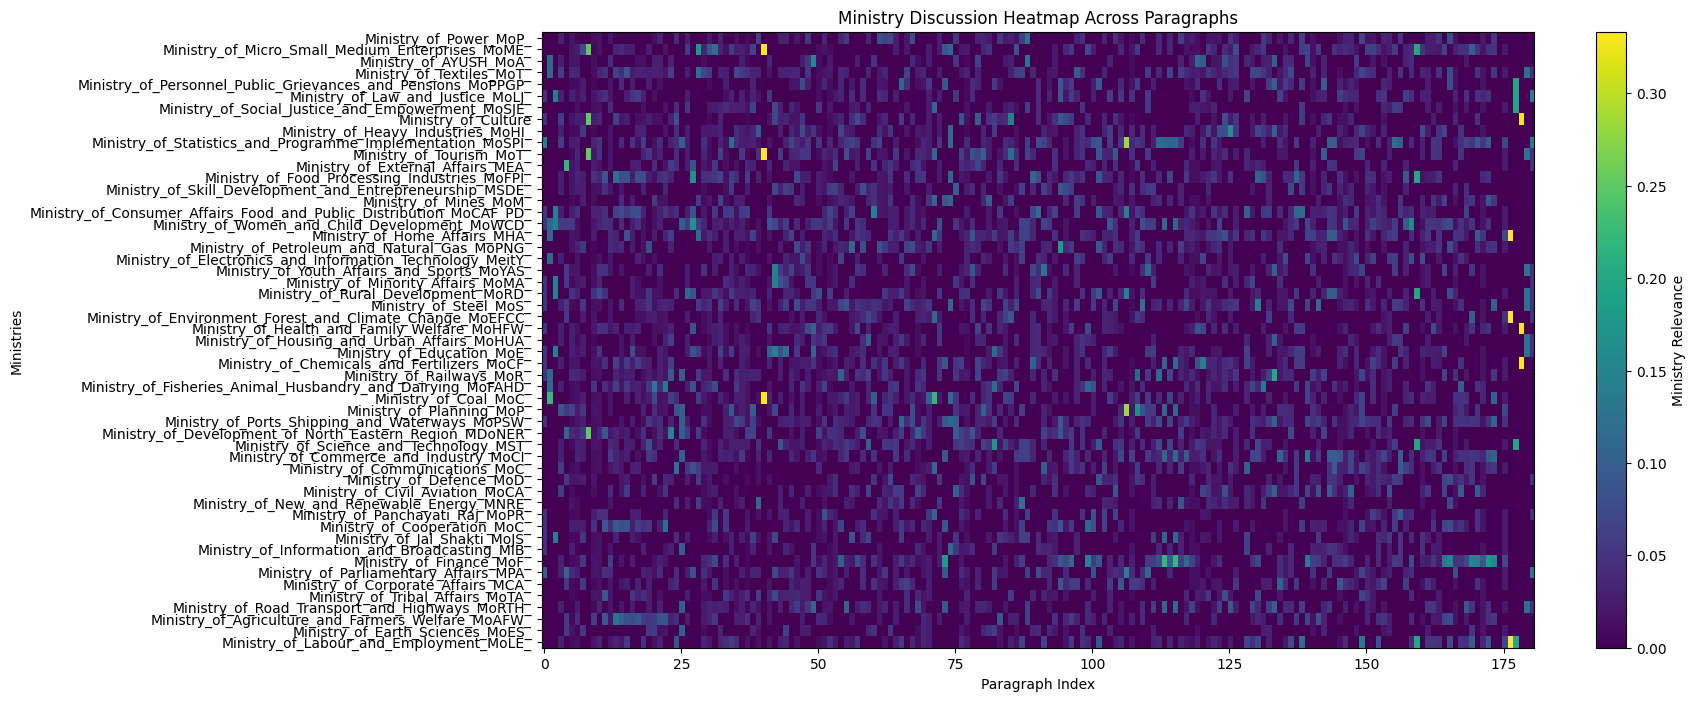

In [90]:
matrix, ministries = build_heatmap_matrix(results, "vocab")

plot_ministry_heatmap(matrix, ministries)

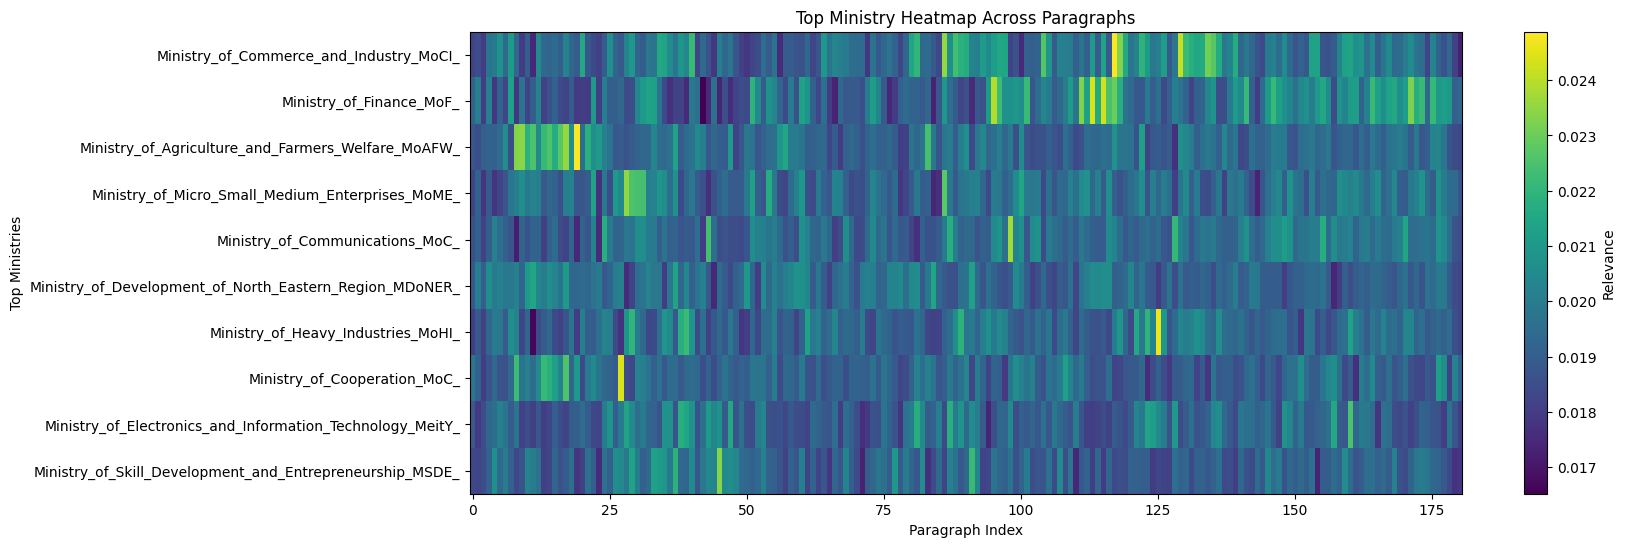

In [91]:
def plot_top_ministry_heatmap(matrix, ministries, top_k=10):

    ministry_scores = matrix.sum(axis=1)

    top_idx = np.argsort(ministry_scores)[::-1][:top_k]

    top_matrix = matrix[top_idx]
    top_ministries = [ministries[i] for i in top_idx]

    plt.figure(figsize=(16,6))

    plt.imshow(top_matrix, aspect='auto')

    plt.colorbar(label="Relevance")

    plt.yticks(range(top_k), top_ministries)

    plt.xlabel("Paragraph Index")
    plt.ylabel("Top Ministries")

    plt.title("Top Ministry Heatmap Across Paragraphs")

    plt.show()
    
matrix, ministries = build_heatmap_matrix(results)

plot_top_ministry_heatmap(matrix, ministries)

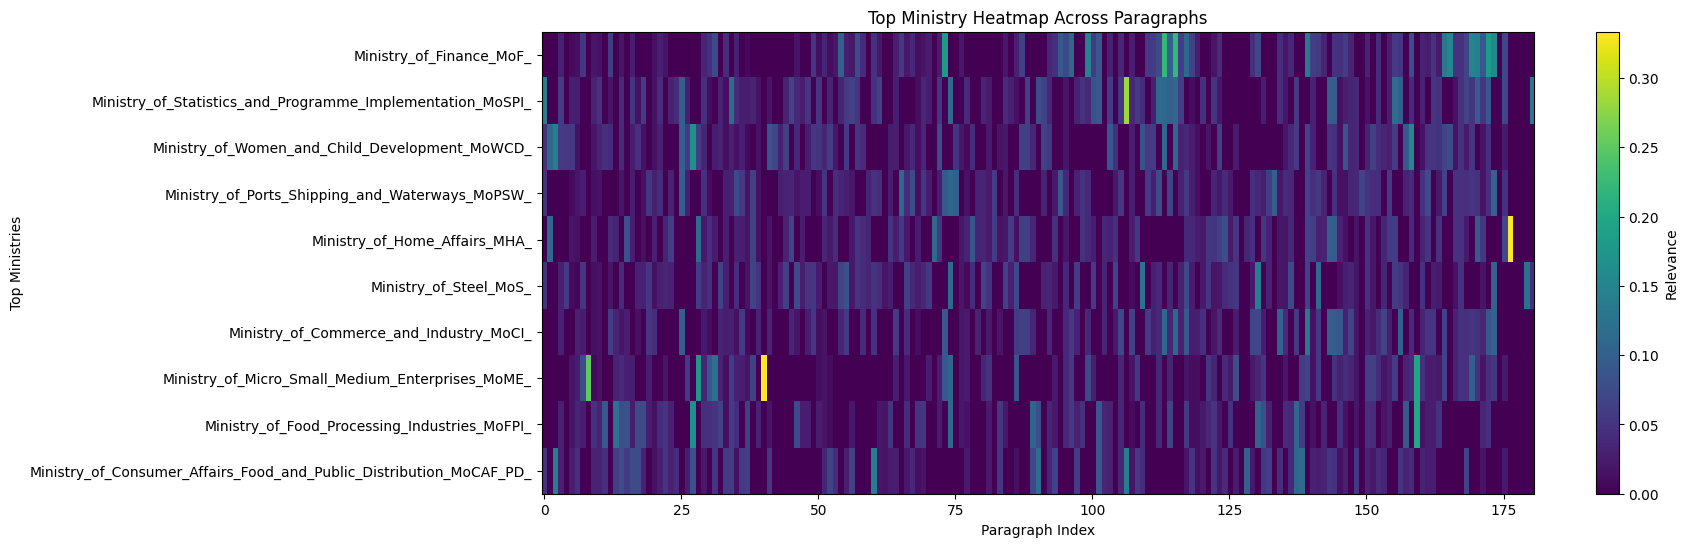

In [92]:
matrix, ministries = build_heatmap_matrix(results, method="vocab")

plot_top_ministry_heatmap(matrix, ministries)

In [93]:
from collections import defaultdict

def build_speaker_ministry_matrix(results, method="embedding"):

    speaker_ministry = defaultdict(lambda: defaultdict(float))

    for item in results:

        speaker = item["speaker"]

        dist = item[f"{method}_distribution"]

        for ministry, prob in dist.items():
            speaker_ministry[speaker][ministry] += prob

    speakers = list(speaker_ministry.keys())
    ministries = list(next(iter(speaker_ministry.values())).keys())

    matrix = np.zeros((len(speakers), len(ministries)))

    for i, spk in enumerate(speakers):
        for j, minstry in enumerate(ministries):

            matrix[i, j] = speaker_ministry[spk][minstry]

    # ministers dominate because they speak more
    # it should show speaker focus instead of speaker volume
    # so normalize rows to sum to 1
    matrix = matrix / (matrix.sum(axis=0, keepdims=True) + 1e-9)
    
    return matrix, speakers, ministries

In [94]:
def select_top_ministries(matrix, ministries, top_k=10):

    scores = matrix.sum(axis=0)

    top_idx = np.argsort(scores)[::-1][:top_k]

    new_matrix = matrix[:, top_idx]

    new_ministries = [ministries[i] for i in top_idx]

    return new_matrix, new_ministries

In [95]:
import seaborn as sns

def plot_speaker_ministry_heatmap(matrix, speakers, ministries):

    plt.figure(figsize=(14,8))

    sns.heatmap(
        matrix,
        xticklabels=ministries,
        yticklabels=speakers,
        cmap="YlOrRd"
    )

    plt.xlabel("Ministry")
    plt.ylabel("Speaker")

    plt.title("Speaker × Ministry Discussion Heatmap")

    plt.show()

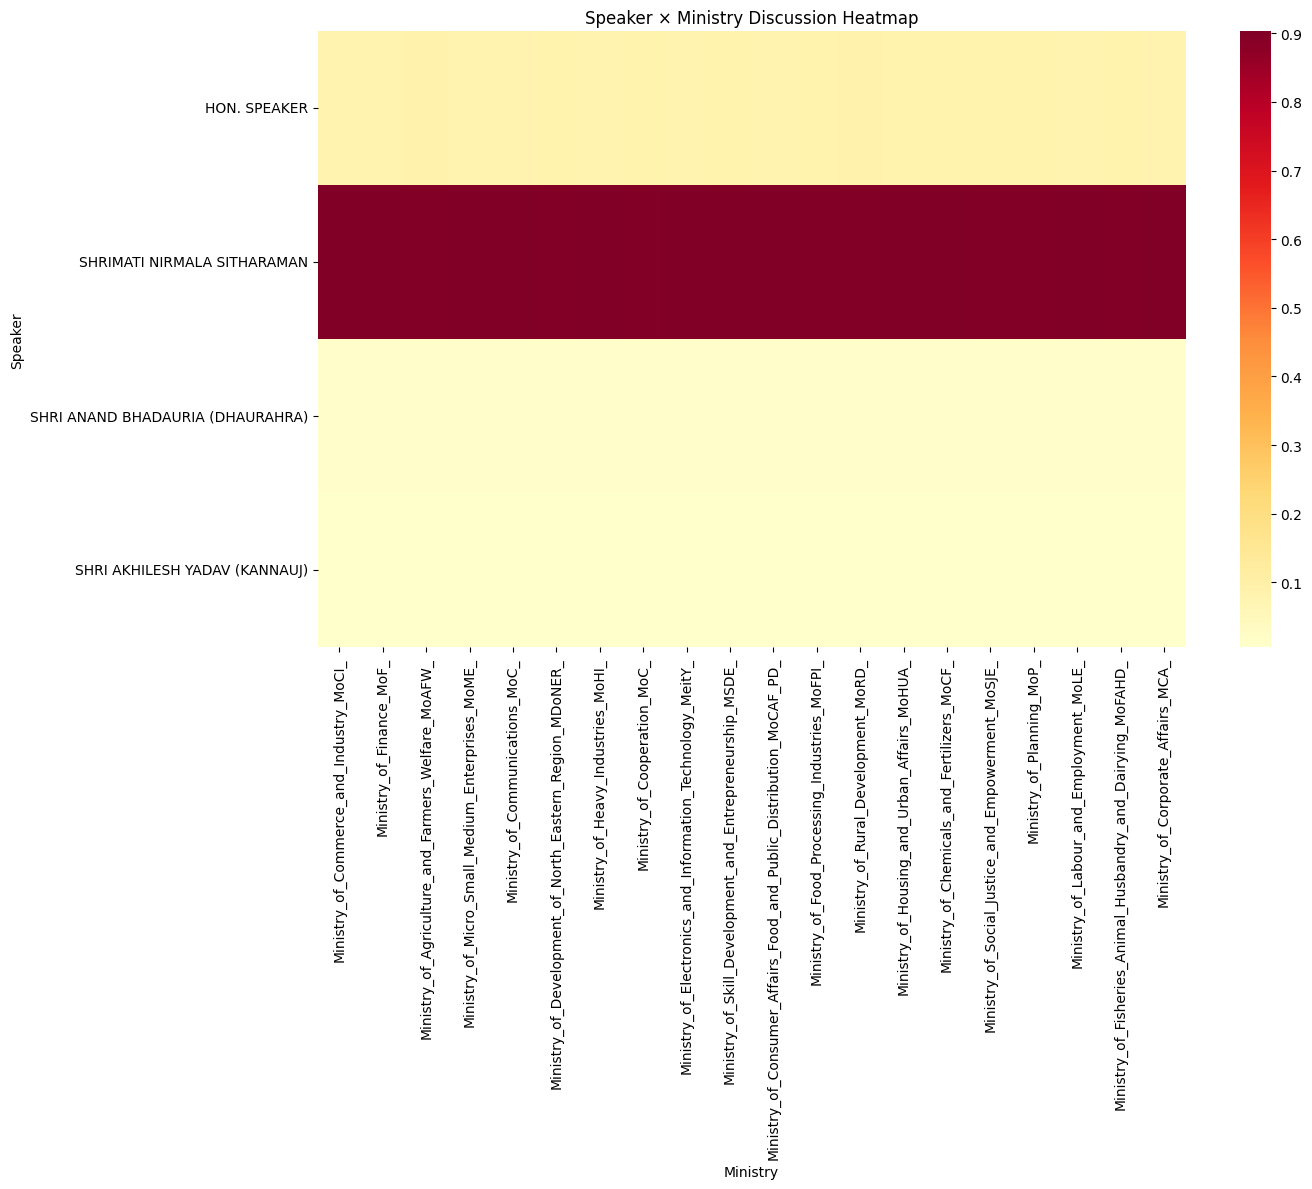

In [96]:
matrix, speakers, ministries = build_speaker_ministry_matrix(results, method="embedding")

matrix, ministries = select_top_ministries(matrix, ministries, top_k=20)

plot_speaker_ministry_heatmap(matrix, speakers, ministries)

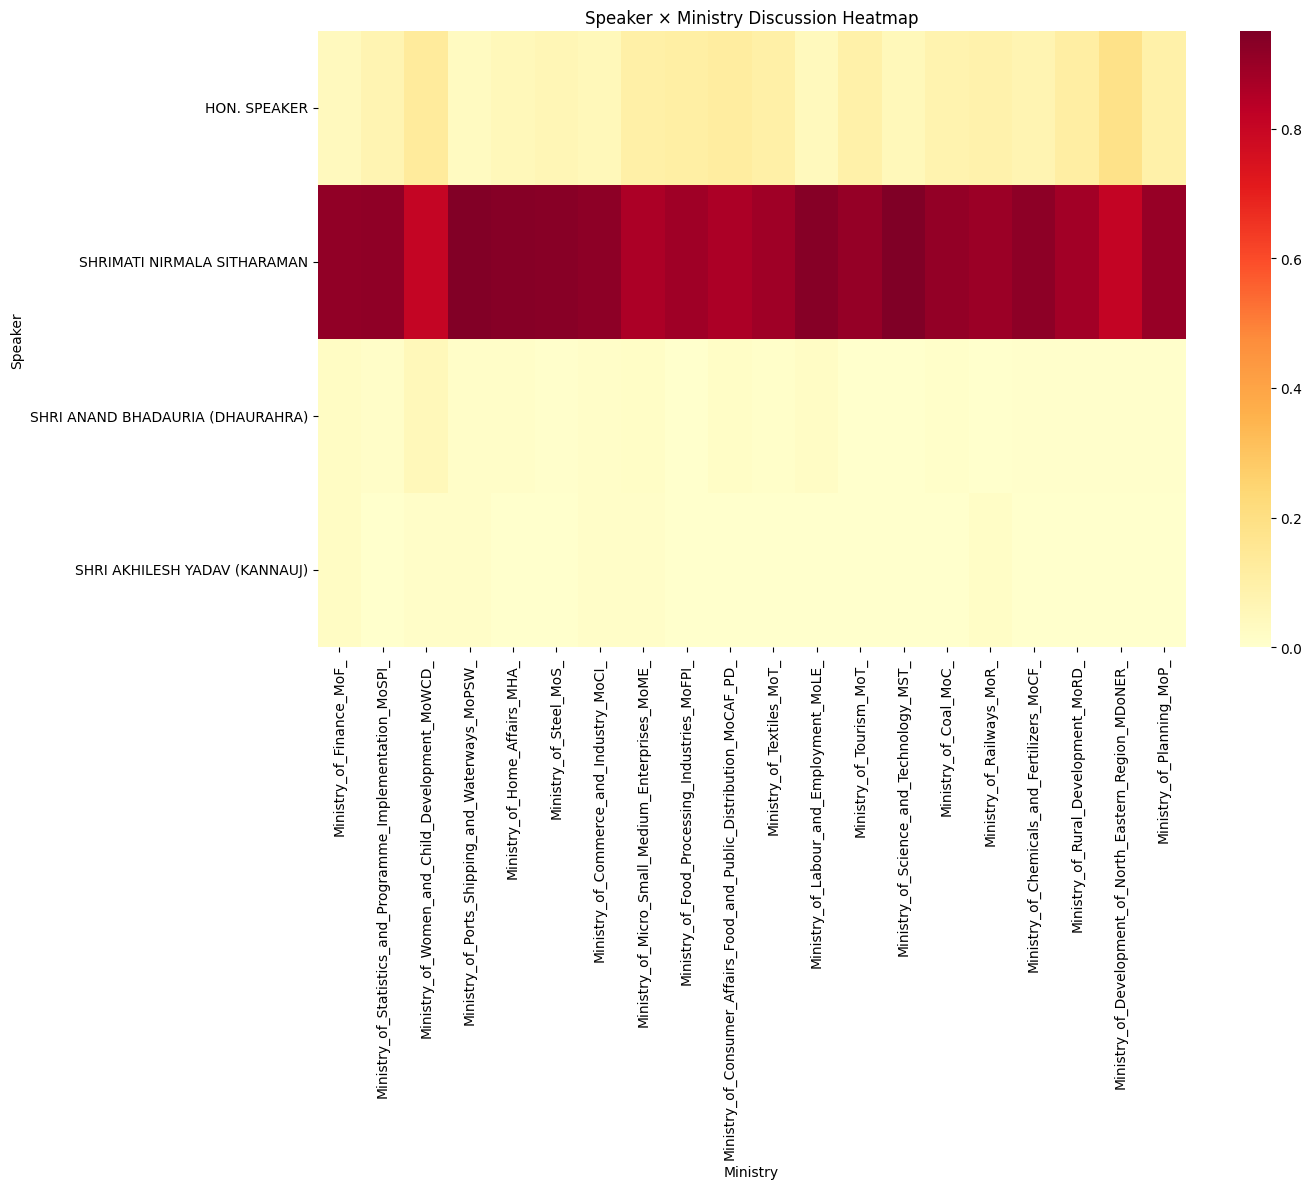

In [97]:
matrix, speakers, ministries = build_speaker_ministry_matrix(results, method="vocab")

matrix, ministries = select_top_ministries(matrix, ministries, top_k=20)

plot_speaker_ministry_heatmap(matrix, speakers, ministries)

In [ ]:
# def get_paragraph_labels(results, method="embedding"):

#     labels = []

#     for item in results:

#         dist = item[f"{method}_distribution"]

#         ministry = max(dist, key=dist.get)

#         labels.append(ministry)

#     return labels


# def build_transition_matrix(labels):

#     transitions = defaultdict(lambda: defaultdict(int))

#     for i in range(len(labels)-1):

#         src = labels[i]
#         dst = labels[i+1]

#         transitions[src][dst] += 1

#     return transitions


# import networkx as nx

# def build_transition_graph(transitions):

#     G = nx.DiGraph()

#     for src in transitions:
#         for dst in transitions[src]:

#             weight = transitions[src][dst]

#             G.add_edge(src, dst, weight=weight)

#     return G


# def plot_transition_graph(G):

#     plt.figure(figsize=(12,8))

#     pos = nx.spring_layout(G, k=0.8)

#     weights = [G[u][v]['weight'] for u,v in G.edges()]

#     nx.draw(
#         G,
#         pos,
#         with_labels=True,
#         node_size=2500,
#         font_size=8,
#         width=weights
#     )

#     plt.title("Ministry Topic Transition Graph")

#     plt.show()
    
# labels = get_paragraph_labels(results, method="embedding")

# transitions = build_transition_matrix(labels)

# G = build_transition_graph(transitions)

# plot_transition_graph(G)